# 01 - Data Understanding: Data Quality Inspection
---
This notebook performs an initial inspection of the dataset in order to verify data quality issues:
1. Accuracy: conformity of the stored value to the actual value.
2. Completeness: no missing values.
3. Consistency: uniform representation.
4. Up-to-dateness: stored data is not obsolete.

It loads the dataset from `data/external/` and :
- identifies the presence of missing values;
- check the class balance;
- identifies the presence of duplicate values.

The notebook does not perform the final cleaning phase and does not store the cleaned dataset.

## Import libraries and settings

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fraud_dynamic_ensemble.config import EXTERNAL_DATA_DIR, FIGURES_DIR

2025-11-08 18:16:51.389 | INFO     | fraud_dynamic_ensemble.config:<module>:12 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
input_path : Path = EXTERNAL_DATA_DIR / "creditcardfraud.csv"
print(f"Loading dataset at path:\n\t{input_path}")

Loading dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/data/external/creditcardfraud.csv


In [3]:
FIGURES_DATA_QUALITY_DIR = FIGURES_DIR / "data_quality_inspection"
FIGURES_DATA_QUALITY_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 16})

## Data Loading
We begin by loading the credit card fraud dataset. This is the untouched file downloaded from Kaggle. It contains anonymized PCA components (`V1`–`V28`), `Time`, `Amount`, and the `Class` label.


In [5]:
df = pd.read_csv(input_path, header=0, sep=",")
print(f"Dataset dimension\n"
      f"\t-Number of rows = {df.shape[0]}\n"
      f"\t-Number of cols = {df.shape[1]}")

Dataset dimension
	-Number of rows = 284807
	-Number of cols = 31


In [6]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [7]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,-0.284708,-0.612982,-0.066655,-0.732987,0.237948,-0.293959,-0.245496,-0.174846,-0.891169,-0.290491,-0.139512,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,-0.111640,-1.109232,-0.453235,-1.046946,1.122674,1.243518,-1.431897,0.939328,-0.002373,2.894952,0.006666,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,-0.594242,-1.264072,0.453596,-0.243142,-0.858719,-0.766554,-0.644646,0.447184,0.388721,0.792135,0.348176,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,0.267772,0.523316,0.559047,-0.834660,0.626211,-0.541494,0.225361,-0.605252,-0.163049,0.561695,-0.256922,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,-0.657422,0.644837,0.190916,-0.546329,-0.731707,-0.808036,0.599628,0.070441,0.373110,0.128904,0.000676,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Missing Values Analysis

### Visual Inspection

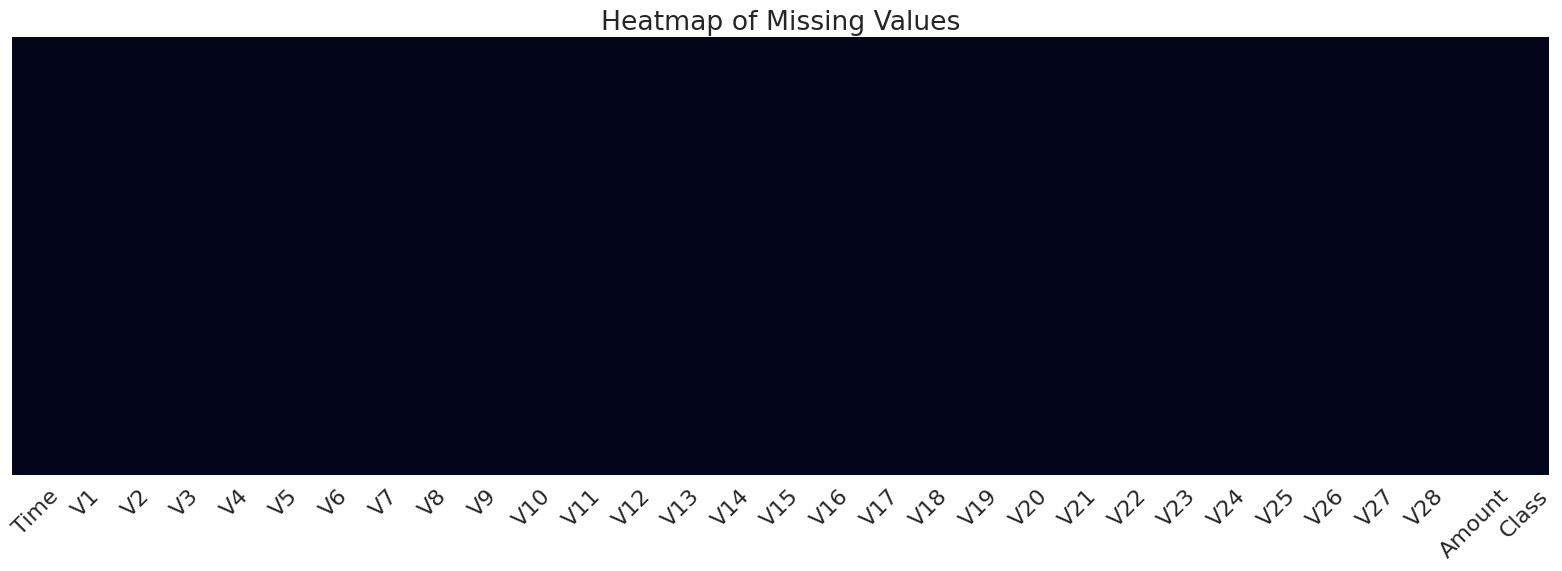

In [9]:
plt.figure(figsize=(16, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Heatmap of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DATA_QUALITY_DIR / "missing_values.png", dpi=300)
plt.show()

### Column-Level Analysis
Missing data may indicate corruption, incomplete exports, or systematic recording errors.

- **Justification:** Columns with missing data may reduce model performance and require imputation or exclusion.

- **Utility:** This step informs whether any imputation strategies might be necessary later.

In [10]:
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=False)

if null_cols.empty:
    print("No missing values detected in any column.")
else:
    print("Missing values per column:")
    for col, n_missing in null_cols.items():
        print(f"\t-{col}: {n_missing} ({n_missing / df.shape[0] * 100:.3f}%)")

No missing values detected in any column.


### Row-Level Analysis
Rows with mostly missing data are likely not salvageable.

- **Justification:** Imputing >50% of a row's content introduces too much uncertainty.

- **Utility:** Prevents noisy, unreliable rows from corrupting the model training phase.

In [11]:
n_before = df.shape[0]

# Keep the % of null in each row
rows_null_percent = df.isnull().mean(axis=1) * 100

pd.DataFrame(rows_null_percent, columns=["null_percent"])

,null_percent
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
284802,0.0
284803,0.0
284804,0.0
284805,0.0


In [12]:
# Keep the index of rows with more than 50% of columns with null values
rows_null_idx = df[rows_null_percent > 50].index

pd.DataFrame(rows_null_idx)

,0


In [13]:
# Number of rows with more than 50% of columns with null values
n_rows_null = len(rows_null_idx)

print(f"Number of rows with >50% null: {n_rows_null}/{n_before} "
      f"({n_rows_null / n_before * 100:.3f}%)")

Number of rows with >50% null: 0/284807 (0.000%)


## Class Balance
We inspect the target distribution to check class balance.

- **Justification:** In fraud detection, we expect a very small percentage of transactions to be fraudulent.

In [14]:
print("Samples distribution by class:")
class_counts = df['Class'].value_counts()
total = class_counts.sum()
for label, count in class_counts.items():
    print(f"\t-Class {label}: {count} ({count / total * 100:.3f}%)")

Samples distribution by class:
	-Class 0: 284315 (99.827%)
	-Class 1: 492 (0.173%)


## Duplicate Row Detection

Duplicate transactions may occur due to export processes or data corruption. They can bias models and falsely inflate evaluation metrics.

- **Justification:** In fraud detection, duplicates may lead to data leakage and overfitting.

- **Utility:** Ensures that each transaction is a unique signal.

### Check duplicate by all columns (Features + Class)

In [15]:
# Total number of rows
n_total = df.shape[0]

# Total number of duplicated rows
# df.duplicated(keep='first') returns False for each unique row;
# df.duplicated(keep='first') returns True if a row is identical to a preceding row.
n_duplicates = df.duplicated(keep='first').sum()

print(f"Number of duplicate rows: {n_duplicates}/{n_total} ({n_duplicates / n_total * 100:.3f}%)")

Number of duplicate rows: 1081/284807 (0.380%)


In [16]:
# Identify all duplicated rows, including the first time each row appears.
duplicate_rows_all = df[df.duplicated(keep=False)]

In [17]:
# Group by all columns and count identical rows
duplicate_groups = (
    duplicate_rows_all
    .groupby(list(df.columns))
    .size()
    .reset_index(name="Count")

    # Put "Count" as the first column
    # We use a lambda function to reorder the columns: ['Count'] followed by all others.
    .pipe(lambda df_temp: df_temp[['Count'] + [col for col in df_temp.columns if col != 'Count']])
    .sort_values(by="Count", ascending=False)

    # Reset the index (drop=True removes the old index column)
    .reset_index(drop=True)
)

print(f"Found {len(duplicate_groups)} unique duplicated patterns.")
duplicate_groups.head(20)

Found 773 unique duplicated patterns.


,Count,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,18,163152.0,-1.196037,1.585949,2.883976,3.378471,1.511706,3.717077,0.585362,-0.156001,0.122648,4.217934,1.385525,-0.709405,-0.256168,-1.564352,1.693218,-0.785210,-0.228008,-0.412833,0.234834,1.375790,-0.370294,0.524395,-0.355170,-0.869790,-0.133198,0.327804,-0.035702,-0.858197,7.56,0
1,18,163152.0,-1.203617,1.574009,2.889277,3.381404,1.538663,3.698747,0.560211,-0.150911,0.124136,4.220998,1.384569,-0.706897,-0.256274,-1.562583,1.692915,-0.787338,-0.226776,-0.412354,0.234322,1.385597,-0.366727,0.522223,-0.357329,-0.870174,-0.134166,0.327019,-0.042648,-0.855262,1.51,0
2,9,170731.0,2.033492,0.766969,-2.107555,3.631952,1.348594,-0.499907,0.945159,-0.286392,-1.370581,1.653073,-1.600434,-1.510901,-2.143280,1.189850,-0.875588,0.175808,-0.419433,-0.464717,-1.414528,-0.430560,0.241894,0.658545,-0.102644,0.580535,0.643637,0.347240,-0.116618,-0.078601,0.76,0
3,9,43153.0,-2.086016,2.203265,1.654339,2.941050,-1.683045,0.529728,-1.352162,1.793449,-0.723686,0.600365,-0.982212,-0.551636,-1.337000,0.834403,1.251862,0.033455,1.067978,0.160510,0.213087,0.079002,0.216444,0.567241,-0.035345,0.370201,0.157378,0.440341,0.210230,0.090558,0.76,0
4,6,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,4.406806,-4.610756,-1.909488,-9.072711,-0.226074,-6.211557,-6.248145,-3.149247,0.051576,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
5,5,68780.0,0.488552,-0.922367,1.673494,3.003203,-1.465758,0.749788,-0.700551,0.383919,0.511891,0.337366,-0.709190,-0.268924,-1.019959,-0.303537,0.313830,0.541531,-0.068846,-0.113716,-1.644419,0.309299,0.371627,0.606800,-0.222559,0.405858,0.080003,0.148637,0.022034,0.087126,282.98,0
6,5,64947.0,-6.370459,3.306401,1.724991,-1.589581,0.174936,0.232403,2.967884,-3.421005,7.937413,11.515880,3.023644,-0.781401,-1.140026,-5.800852,0.406259,-1.723657,-2.375979,-0.529492,-0.100033,2.943972,-1.614332,0.387513,-0.364322,0.480224,0.154904,-0.535302,-4.787907,-3.696616,12.33,0
7,5,64947.0,-6.373391,3.301783,1.727041,-1.588447,0.185362,0.225313,2.958156,-3.419036,7.937988,11.517065,3.023275,-0.780431,-1.140067,-5.800167,0.406141,-1.724479,-2.375503,-0.529306,-0.100230,2.947765,-1.612952,0.386673,-0.365157,0.480075,0.154530,-0.535606,-4.790593,-3.695480,9.99,0
8,5,64947.0,-6.342969,3.349697,1.705767,-1.600219,0.077178,0.298877,3.059092,-3.439462,7.932015,11.504768,3.027109,-0.790496,-1.139641,-5.807267,0.407360,-1.715942,-2.380449,-0.531228,-0.098178,2.908407,-1.627268,0.395387,-0.356491,0.481618,0.158414,-0.532454,-4.762716,-3.707261,34.27,0
9,5,64947.0,-6.378440,3.293830,1.730572,-1.586493,0.203319,0.213103,2.941403,-3.415646,7.938980,11.519106,3.022639,-0.778760,-1.140137,-5.798989,0.405939,-1.725896,-2.374682,-0.528987,-0.100571,2.954298,-1.610576,0.385227,-0.366595,0.479819,0.153885,-0.536129,-4.795220,-3.693525,5.96,0


Check the frequency, that is how many patterns have N duplicates.

Number of unique duplicate patterns by repetition count:
	-   611 different patterns duplicated   2 times
	-    66 different patterns duplicated   3 times
	-    81 different patterns duplicated   4 times
	-    10 different patterns duplicated   5 times
	-     1 different patterns duplicated   6 times
	-     2 different patterns duplicated   9 times
	-     2 different patterns duplicated  18 times


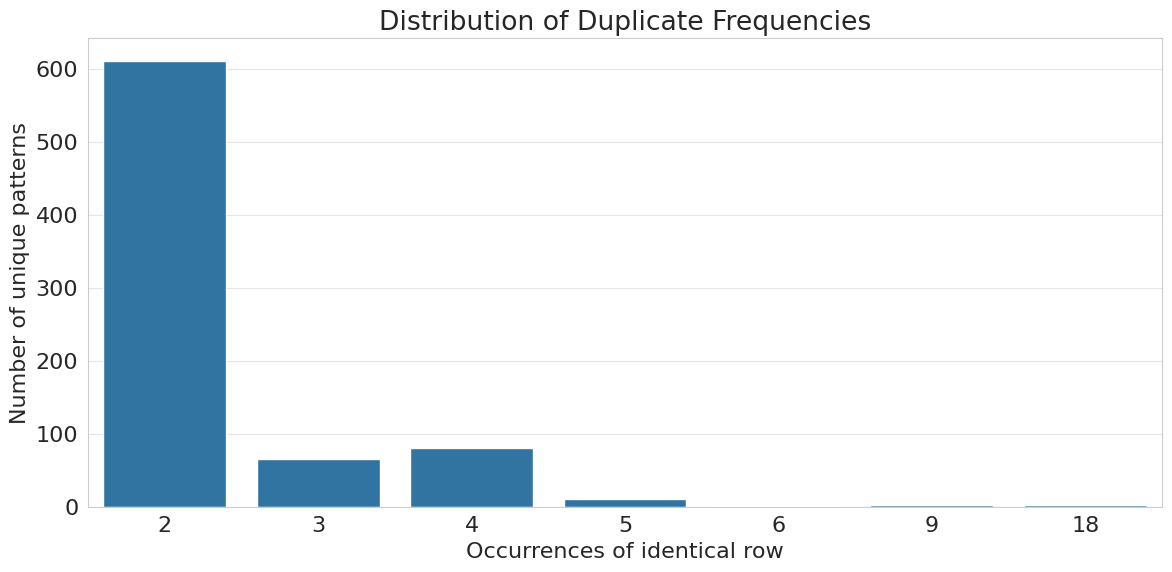

In [18]:
duplication_frequency = duplicate_groups['Count'].value_counts().sort_index()

print("Number of unique duplicate patterns by repetition count:")
for repetition, num_groups in duplication_frequency.items():
    print(f"\t-{num_groups:6} different patterns duplicated {repetition:3} times")

plt.figure(figsize=(12, 6))
sns.barplot(x=duplication_frequency.index, y=duplication_frequency.values)
plt.xlabel("Occurrences of identical row")
plt.ylabel("Number of unique patterns")
plt.title("Distribution of Duplicate Frequencies")
plt.grid(True, axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DATA_QUALITY_DIR / "duplicated_frequency_distribution.png", dpi=300)
plt.show()

### Check duplicate by only Features

In [19]:
# Total number of duplicated rows
# df.duplicated(keep='first') returns False for each unique row;
# df.duplicated(keep='first') returns True if a row is identical to a preceding row.
n_duplicates = df.duplicated(keep='first', subset=df.columns.drop('Class').tolist()).sum()

print(f"Number of duplicate rows: {n_duplicates}/{n_total} ({n_duplicates / n_total * 100:.3f}%)")

Number of duplicate rows: 1081/284807 (0.380%)


We are working with the Credit Card Fraud Detection dataset, which contains:

- Time (in seconds)

- Amount

- 28 PCA-transformed features

- Class

When two rows match exactly in all fields, including Time, it's a very strong signal that they’re not two independent real transactions, but instead a copied entry.

Given the time (precise to the second), the amount (float) and 28 PCs, the probability that two truly distinct events would produce identical values in all 31 columns (with and without `Class`) is low, even if the same user repeated the action.

This makes true accidental “real” duplication almost impossible.

---

If we leave exact duplicates in the dataset:

1. Bias in the model—The classifier will “see” repeated evidence of the same row. This gives unfair influence to those examples during training.

2. Risk of overfitting—Especially with a small number of fraud cases, repeating exact Class 1 samples inflates the model's confidence.

3. Invalidation of cross-validation—Duplicates might leak into both training and validation folds. This leads to optimistically biased performance metrics (especially precision/recall).

Based on these considerations, we adopt the choice of dropping duplicated rows, keeping each of them just one time.